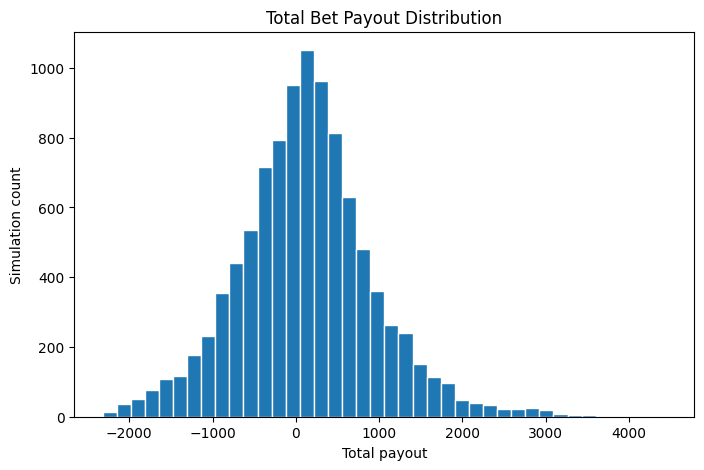

,expected_payout,standard_deviation,min,max
bet,,,,
Ecuador C20 36 @ 6.75,-94.8960,447.284613,-243.0,2997.0
France P20 50 @ 1.5,-51.6500,72.748041,-75.0,175.0
Netherlands F -10 @ 30,-47.5750,259.147389,-850.0,150.0
Netherlands C20 -10 @ 13,-39.3250,243.263837,-820.0,130.0
Uruguay C20 5 @ 7,-22.1475,53.600380,-35.0,415.0
Ghana P20 1 @ 12,-3.6885,3.208032,-12.0,3.0
Uruguay C80 2 @ 0.5,-0.6990,3.583211,-1.0,59.0
France F -5 @ 50,19.5550,149.202805,-350.0,175.0
Switzerland F 5 @ 23,21.9600,84.943854,-40.0,460.0


In [99]:
import json
import re
from difflib import get_close_matches
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.image as mpimg
import matplotlib.image as mpimg
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SIM_META_PATH = Path("model_output/simulation_runs_meta.json")
SIM_RUNS_PATH = Path("model_output/simulation_runs.jsonl")
BETS_PATH = Path("bets.txt")

PROGRESSION_STAGE_VALUES = {
    "Round of 32": 5.0,
    "Round of 16": 10.0,
    "Quarterfinal": 20.0,
    "Semifinal": 40.0,
    "Final": 60.0,
    "Champion": 80.0,
}
WIN_VALUE_PER_90 = 5.0

with SIM_META_PATH.open("r") as f:
    meta = json.load(f)

with SIM_RUNS_PATH.open("r") as f:
    simulation_rows = [json.loads(line) for line in f if line.strip()]

teams = meta["teams"]
stages = meta["stages"]
team_to_id = {team: idx for idx, team in enumerate(teams)}


def canonicalize_team_name(raw_team: str):
    team = raw_team.strip()
    if team in team_to_id:
        return team, None
    matches = get_close_matches(team, teams, n=1, cutoff=0.7)
    if not matches:
        raise ValueError(f"Unknown team in bets.txt: {raw_team!r}")
    return matches[0], f"Mapped team {raw_team!r} to {matches[0]!r}"


def parse_bet_line(line: str, line_no: int) -> dict:
    cleaned = line.strip()
    if not cleaned:
        raise ValueError("Empty bet line")
    if " & " in cleaned:
        cleaned = cleaned.replace(" & ", " @ ")
        separator_note = f"Replaced '&' with '@' on line {line_no}"
    else:
        separator_note = None

    match = re.fullmatch(
        r"(?P<team>.+?)\s+(?P<contract>F|C(?P<call_strike>\d+)|P(?P<put_strike>\d+))\s+(?P<lots>[+-]?\d+(?:\.\d+)?)\s*@\s*(?P<price>[+-]?\d+(?:\.\d+)?)",
        cleaned,
    )
    if not match:
        raise ValueError(f"Could not parse bet line {line_no}: {line!r}")

    team, team_note = canonicalize_team_name(match.group("team"))
    contract = match.group("contract")
    lots = float(match.group("lots"))
    price = float(match.group("price"))

    if contract == "F":
        instrument_type = "future"
        strike = None
        instrument_key = (team, instrument_type, strike)
    elif contract.startswith("C"):
        instrument_type = "call"
        strike = int(match.group("call_strike"))
        instrument_key = (team, instrument_type, strike)
    else:
        instrument_type = "put"
        strike = int(match.group("put_strike"))
        instrument_key = (team, instrument_type, strike)

    notes = [note for note in [separator_note, team_note] if note]
    return {
        "line_no": line_no,
        "raw_line": line,
        "team": team,
        "instrument_type": instrument_type,
        "strike": strike,
        "lots": lots,
        "price": price,
        "instrument_key": instrument_key,
        "notes": notes,
    }


def compute_team_total_values(sim_records):
    team_count = len(teams)
    total_values = np.zeros((len(sim_records), team_count), dtype=float)
    for sim_idx, record in enumerate(sim_records):
        run_progression_value = np.zeros(team_count, dtype=float)
        run_win_value = np.zeros(team_count, dtype=float)
        for match in record.get("m", []):
            stage_name = stages[match[0]]
            home_id = int(match[2])
            away_id = int(match[3])
            home_score = int(match[4])
            away_score = int(match[5])
            went_penalties = bool(match[7])
            penalty_winner_id = int(match[8])
            home_score_90 = int(match[9])
            away_score_90 = int(match[10])

            if stage_name == "Group":
                if home_score > away_score:
                    run_win_value[home_id] += WIN_VALUE_PER_90
                elif away_score > home_score:
                    run_win_value[away_id] += WIN_VALUE_PER_90
                continue

            if home_score_90 > away_score_90:
                run_win_value[home_id] += WIN_VALUE_PER_90
            elif away_score_90 > home_score_90:
                run_win_value[away_id] += WIN_VALUE_PER_90

            if went_penalties and penalty_winner_id != -1:
                winner = penalty_winner_id
            elif home_score > away_score:
                winner = home_id
            else:
                winner = away_id
            loser = away_id if winner == home_id else home_id

            if stage_name in ("Round of 32", "Round of 16", "Quarterfinal", "Semifinal"):
                run_progression_value[loser] = PROGRESSION_STAGE_VALUES[stage_name]
            elif stage_name == "Final":
                run_progression_value[loser] = PROGRESSION_STAGE_VALUES["Final"]
                run_progression_value[winner] = PROGRESSION_STAGE_VALUES["Champion"]

        total_values[sim_idx] = run_progression_value + run_win_value
    return total_values


parsed_bets = []
parse_notes = []
for line_no, raw_line in enumerate(BETS_PATH.read_text().splitlines(), start=1):
    stripped = raw_line.strip()
    if not stripped:
        continue
    bet = parse_bet_line(stripped, line_no)
    parsed_bets.append(bet)
    parse_notes.extend(bet["notes"])

bets_raw_df = pd.DataFrame(parsed_bets)

aggregated_rows = []
for instrument_key, sub in bets_raw_df.groupby("instrument_key", sort=True):
    team, instrument_type, strike = instrument_key
    net_lots = sub["lots"].sum()
    total_cost = (sub["lots"] * sub["price"]).sum()
    average_price = total_cost / net_lots if abs(net_lots) > 1e-12 else np.nan
    if instrument_type == "future":
        label = f"{team} F {net_lots:g} @ {average_price:g}"
    elif instrument_type == "call":
        label = f"{team} C{strike} {net_lots:g} @ {average_price:g}"
    else:
        label = f"{team} P{strike} {net_lots:g} @ {average_price:g}"
    aggregated_rows.append(
        {
            "bet": label,
            "team": team,
            "instrument_type": instrument_type,
            "strike": strike,
            "net_lots": net_lots,
            "total_cost": total_cost,
        }
    )

bets_aggregated_df = (
    pd.DataFrame(aggregated_rows)
    .sort_values(["team", "instrument_type", "strike"], na_position="first")
    .reset_index(drop=True)
)

team_total_values = compute_team_total_values(simulation_rows)

bet_payoff_series = {}
for row in bets_aggregated_df.itertuples(index=False):
    team_id = team_to_id[row.team]
    intrinsic = team_total_values[:, team_id]
    if row.instrument_type == "call":
        intrinsic = np.maximum(intrinsic - row.strike, 0.0)
    elif row.instrument_type == "put":
        intrinsic = np.maximum(row.strike - intrinsic, 0.0)
    payout = row.net_lots * intrinsic - row.total_cost
    bet_payoff_series[row.bet] = payout

bet_payoffs_df = pd.DataFrame(bet_payoff_series)
if bet_payoffs_df.empty:
    raise ValueError("No non-empty bets parsed from bets.txt")

total_payoff_series = bet_payoffs_df.sum(axis=1)

summary_rows = []
for bet_name in bet_payoffs_df.columns:
    payouts = bet_payoffs_df[bet_name].to_numpy()
    summary_rows.append(
        {
            "bet": bet_name,
            "expected_payout": float(payouts.mean()),
            "standard_deviation": float(payouts.std(ddof=0)),
            "min": float(payouts.min()),
            "max": float(payouts.max()),
        }
    )

summary_rows.append(
    {
        "bet": "Total",
        "expected_payout": float(total_payoff_series.mean()),
        "standard_deviation": float(total_payoff_series.std(ddof=0)),
        "min": float(total_payoff_series.min()),
        "max": float(total_payoff_series.max()),
    }
)

bets_summary_df = pd.DataFrame(summary_rows).set_index("bet")
parse_notes_series = (
    pd.Series(parse_notes, name="parse_note")
    if parse_notes
    else pd.Series(dtype=object, name="parse_note")
)

ax = total_payoff_series.plot.hist(bins=40, figsize=(8, 5), edgecolor="white")
ax.set_title("Total Bet Payout Distribution")
ax.set_xlabel("Total payout")
ax.set_ylabel("Simulation count")
plt.show()

bets_summary_df.sort_values("expected_payout")

In [106]:
from IPython.display import Markdown, display

def simulation_matches_df(sim_index: int) -> pd.DataFrame:
    record = simulation_rows[sim_index]
    rows = []
    for match in record["m"]:
        stage_name = stages[match[0]]
        home_team = teams[int(match[2])]
        away_team = teams[int(match[3])]
        home_score = int(match[4])
        away_score = int(match[5])
        rows.append(
            {
                "stage": stage_name,
                "home_team": home_team,
                "away_team": away_team,
                "score": f"{home_score}-{away_score}",
            }
        )
    return pd.DataFrame(rows)


def describe_simulation(sim_index: int, label: str):
    total_payoff = float(total_payoff_series.iloc[sim_index])
    bet_payouts = bet_payoffs_df.iloc[sim_index].sort_values(ascending=False)
    worst_bets = bet_payouts.sort_values().head(5).rename("payout")
    best_bets = bet_payouts.head(5).rename("payout")
    teams_in_book = sorted(bets_aggregated_df["team"].unique())
    team_values = (
        pd.Series({team: float(team_total_values[sim_index, team_to_id[team]]) for team in teams_in_book})
        .sort_values(ascending=False)
        .rename("team_value")
    )
    matches_df = simulation_matches_df(sim_index)
    final_match = matches_df.loc[matches_df["stage"] == "Final"].tail(1)

    display(Markdown(f"## {label} Simulation"))
    display(pd.DataFrame({"sim_index": [sim_index], "total_payoff": [total_payoff]}))
    if not final_match.empty:
        display(Markdown("**Final**"))
        display(final_match.reset_index(drop=True))
    display(Markdown("**Top 5 winning bets**"))
    display(best_bets.to_frame())
    display(Markdown("**Top 5 losing bets**"))
    display(worst_bets.to_frame())
    display(Markdown("**Booked teams by simulated team value**"))
    display(team_values.to_frame())
    display(Markdown("**Knockout bracket**"))
    display(matches_df.loc[matches_df["stage"] != "Group"].reset_index(drop=True))


best_sim_index = int(total_payoff_series.idxmax())
worst_sim_index = int(total_payoff_series.idxmin())

describe_simulation(best_sim_index, "Best")
describe_simulation(worst_sim_index, "Worst")

## Best Simulation

,sim_index,total_payoff
0,9031,4449.0


**Final**

,stage,home_team,away_team,score
0,Final,Canada,Ecuador,1-2


**Top 5 winning bets**

...

,payout
Netherlands F -10 @ 30,-850.0
Netherlands C20 -10 @ 13,-820.0
Ecuador C20 36 @ 6.75,-243.0
Argentina F 5 @ 43,-115.0
Colombia F 10 @ 26,-110.0


**Booked teams by simulated team value**

,team_value
Netherlands,115.0
France,65.0
Uruguay,35.0
Argentina,20.0
Canada,20.0
Colombia,15.0
Ghana,15.0
Switzerland,15.0
Ecuador,10.0


**Knockout bracket**

,stage,home_team,away_team,score
0,Round of 32,South Africa,Canada,0-1
1,Round of 32,Germany,Sweden,2-3
2,Round of 32,Netherlands,Morocco,2-0
3,Round of 32,Brazil,Japan,3-1
4,Round of 32,Norway,Saudi Arabia,6-0
5,Round of 32,Ivory Coast,France,1-2
6,Round of 32,Mexico,Ecuador,5-0
7,Round of 32,England,Senegal,1-1
8,Round of 32,USA,Bosnia and Herzegovina,0-0
9,Round of 32,Egypt,South Korea,1-0


In [104]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

SIM_META_PATH = Path("model_output/simulation_runs_meta.json")
SIM_RUNS_PATH = Path("model_output/simulation_runs.jsonl")

with SIM_META_PATH.open("r") as f:
    sim_meta = json.load(f)

with SIM_RUNS_PATH.open("r") as f:
    simulation_rows = [json.loads(line) for line in f if line.strip()]

teams = sim_meta["teams"]
stages = sim_meta["stages"]
round_of_32_stage_id = stages.index("Round of 32")

combo_counts = defaultdict(int)
combo_finish_third_counts = defaultdict(int)
combo_finish_third_and_r32_counts = defaultdict(int)

for sim in simulation_rows:
    group_rankings = sim["gr"]
    group_tables = sim["gt"]
    r32_teams = set()
    for match in sim["m"]:
        if int(match[0]) != round_of_32_stage_id:
            continue
        r32_teams.add(int(match[2]))
        r32_teams.add(int(match[3]))

    for ranking, table in zip(group_rankings, group_tables):
        team_to_rank = {int(team_id): rank for rank, team_id in enumerate(ranking, start=1)}
        for row in table:
            team_id = int(row[0])
            points = int(row[1])
            gd = int(row[2])
            gf = int(row[3])
            combo = (points, gd, gf)
            combo_counts[combo] += 1
            rank = team_to_rank[team_id]
            if rank == 3:
                combo_finish_third_counts[combo] += 1
                if team_id in r32_teams:
                    combo_finish_third_and_r32_counts[combo] += 1

records = []
for combo in sorted(combo_counts):
    total_count = combo_counts[combo]
    third_count = combo_finish_third_counts[combo]
    third_and_r32_count = combo_finish_third_and_r32_counts[combo]
    p_finish_third = third_count / total_count if total_count else np.nan
    p_r32_given_third = third_and_r32_count / third_count if third_count else np.nan
    records.append(
        {
            "points": combo[0],
            "gd": combo[1],
            "gf": combo[2],
            "count": total_count,
            "third_count": third_count,
            "third_and_r32_count": third_and_r32_count,
            "p_finish_3rd_given_combo": p_finish_third,
            "p_reach_r32_given_3rd_and_combo": p_r32_given_third,
        }
    )

third_place_combo_df = (
    pd.DataFrame(records)
    .sort_values(["points", "gd", "gf"], ascending=[False, False, False])
    .reset_index(drop=True)
)

third_place_combo_df

,points,gd,gf,count,third_count,third_and_r32_count,p_finish_3rd_given_combo,p_reach_r32_given_3rd_and_combo
0,9,18,18,1,0,0,0.0,NaN
1,9,17,17,1,0,0,0.0,NaN
2,9,16,17,1,0,0,0.0,NaN
3,9,16,16,1,0,0,0.0,NaN
4,9,15,16,3,0,0,0.0,NaN
...,...,...,...,...,...,...,...,...
576,0,-14,3,2,0,0,0.0,NaN
577,0,-14,2,1,0,0,0.0,NaN
578,0,-14,1,6,0,0,0.0,NaN
579,0,-15,2,1,0,0,0.0,NaN


In [105]:
## Preamble ##

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import gamma

from src.model import Model
from src.model_elo import EloModel

def dr(df):
    with pd.option_context('display.max_rows', None):
        display(df)
        
def dc(df):
    with pd.option_context('display.max_columns', None):
        display(df)
        
def drc(df):
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(df)
dcr = drc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
dcr(
    third_place_combo_df.groupby(["points", "gd"]).apply(lambda G: G.third_and_r32_count.sum() / G.third_count.sum()).reset_index()
    .rename(columns={0: "p_reach_r32_given_3rd_and_points_gd"})
    .query("p_reach_r32_given_3rd_and_points_gd.notna()")
    .sort_values(["points", "gd"], ascending=False)
    .set_index(["points", "gd"])
    .unstack().T
)

/var/folders/y9/7mrfwwc97kg93k2qmfccslvm0000gn/T/ipykernel_85848/2623848277.py:2: RuntimeWarning: invalid value encountered in scalar divide
  third_place_combo_df.groupby(["points", "gd"]).apply(lambda G: G.third_and_r32_count.sum() / G.third_count.sum()).reset_index()
/var/folders/y9/7mrfwwc97kg93k2qmfccslvm0000gn/T/ipykernel_85848/2623848277.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  third_place_combo_df.groupby(["points", "gd"]).apply(lambda G: G.third_and_r32_count.sum() / G.third_count.sum()).reset_index()


points                                     1         2         3         4
                                    gd                                    
p_reach_r32_given_3rd_and_points_gd -11  NaN       NaN  0.000000       NaN
                                    -10  NaN       NaN  0.000000       NaN
                                    -9   NaN       NaN  0.000000       NaN
                                    -8   0.0       NaN  0.028571  1.000000
                                    -7   0.0  0.000000  0.135593  1.000000
                                    -6   0.0  0.000000  0.044229  1.000000
                                    -5   0.0  0.000000  0.095159  0.996528
                                    -4   0.0  0.000000  0.223309  1.000000
                                    -3   0.0  0.000000  0.453915  1.000000
                                    -2   0.0  0.000000  0.794530  1.000000
                                    -1   NaN  0.006914  0.943546  1.000000
                                     0   NaN       NaN  0.996807  1.000000
                                     1   NaN       NaN  1.000000  1.000000
                                     2   NaN       NaN  0.992000  1.000000
                                     3   NaN       NaN  1.000000  1.000000
                                     4   NaN       NaN  1.000000  1.000000
                                     5   NaN       NaN       NaN  1.000000
                                     6   NaN       NaN       NaN  1.000000
                                     7   NaN       NaN       NaN  1.000000

In [75]:
import pandas as pd

df = pd.read_csv("model_output/ratings_history_yearly.csv")

In [76]:
df

,date,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Wales,Yemen,Yugoslavia,Zambia,Zimbabwe
0,1872-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1874-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1875-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1876-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,85.869389,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,2022-01-01,22.361351,60.494500,79.486852,1.885216,25.994497,52.904015,4.510627,23.597637,97.254251,...,89.925324,62.147925,19.500100,76.138857,45.163206,78.932527,23.801496,NaN,55.814127,49.981550
151,2023-01-01,19.720088,67.241293,77.057854,1.038643,27.478342,51.391346,4.246947,16.727118,97.644866,...,93.036003,66.842482,18.025784,81.339940,44.762614,77.220149,25.680312,NaN,58.257566,52.142896
152,2024-01-01,22.083272,68.675613,76.145777,1.097468,26.120076,58.596424,4.097176,13.972250,97.622555,...,92.746301,67.100699,14.029964,80.569008,40.241523,78.075987,27.270781,NaN,56.903897,52.011531
153,2025-01-01,20.570777,69.634922,78.148151,1.095468,28.429550,56.059804,4.098839,14.131697,97.972479,...,91.149171,70.493697,15.556168,78.589418,37.320761,78.305369,32.276386,NaN,53.783915,50.494897


In [77]:
df["mu_sum"] = df["mu_attack"] + df["mu_defense"]
df["tilt"] = df["mu_attack"] - df["mu_defense"]

KeyError: 'mu_attack'

<Axes: ylabel='Frequency'>

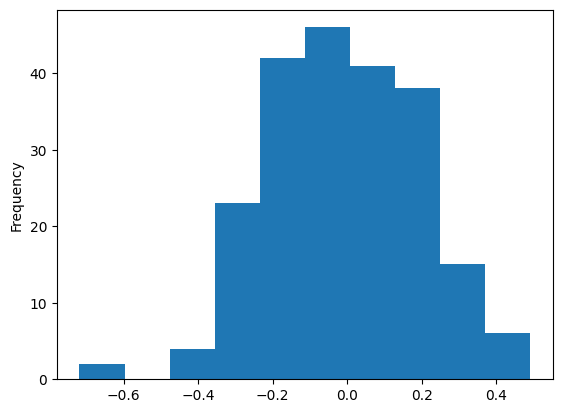

In [ ]:
df.tilt.plot.hist()

In [ ]:
df.sort_values("tilt", ascending=False).head(20)

,team,mu_attack,mu_defense,sigma_attack,sigma_defense,sigma_ad,mu_global,quality,quality_low,mu_attack_low,mu_defense_low,year,rating_attack,rating_defense,rating,mu_sum,tilt
187,St Vincent and the Grenadines,-1.398502,-1.890905,0.020310,0.018437,0.008615,0.265569,-3.289407,-3.762601,-1.683530,-2.162470,2026.0,31.989342,16.858501,23.533678,-3.289407,0.492403
22,Bermuda,-1.423362,-1.898133,0.020603,0.017695,0.007892,0.265569,-3.321495,-3.786603,-1.710436,-2.164177,2026.0,31.053398,16.688028,23.045508,-3.321495,0.474770
77,Germany,0.208238,-0.226568,0.014030,0.018789,0.008157,0.265569,-0.018330,-0.461655,-0.028656,-0.500717,2026.0,97.201333,85.702070,92.738463,-0.018330,0.434807
98,Israel,-0.361825,-0.784555,0.018194,0.016490,0.008487,0.265569,-1.146380,-1.600952,-0.631593,-1.041385,2026.0,80.193660,59.864269,70.381358,-1.146380,0.422729
147,Northern Mariana Islands,-2.961141,-3.352407,0.065210,0.030410,0.017955,0.265569,-6.313548,-7.038893,-3.471867,-3.701177,2026.0,3.098856,1.544665,2.197246,-6.313548,0.391266
10,Aruba,-1.683626,-2.059878,0.026655,0.021713,0.010288,0.265569,-3.743504,-4.268646,-2.010152,-2.354587,2026.0,22.362511,13.224527,17.317005,-3.743504,0.376252
87,Guyana,-1.177801,-1.538767,0.019576,0.020820,0.009284,0.265569,-2.716568,-3.202219,-1.457627,-1.827350,2026.0,41.066706,26.949556,33.541850,-2.716568,0.360965
14,Bahamas,-2.330663,-2.685133,0.031942,0.019298,0.009387,0.265569,-5.015796,-5.545003,-2.688112,-2.962967,2026.0,8.775050,4.953895,6.623703,-5.015796,0.354470
175,Sint Maarten,-1.869083,-2.218117,0.037602,0.023078,0.010326,0.265569,-4.087200,-4.657577,-2.256908,-2.521947,2026.0,17.381695,10.437279,13.543701,-4.087200,0.349035
109,Laos,-2.086331,-2.431170,0.027354,0.017553,0.010536,0.265569,-4.517500,-5.031227,-2.417109,-2.696148,2026.0,12.719231,7.490166,9.808328,-4.517500,0.344839


## Australia vs Paraguay score matrix

This section computes Australia's `Reach R32` probability as a function of the `Paraguay vs Australia` scoreline, bucketed from `0` to `5+` goals for each side. It keeps every other simulated match fixed, swaps only this one match, then recomputes Group D and best-third qualification.


In [107]:
# AUS-PAR R32 MATRIX
import json
import math
from collections import defaultdict

import numpy as np
import pandas as pd

GROUPS = list("ABCDEFGHIJKL")
GROUP_D_INDEX = GROUPS.index("D")
GROUP_D_TEAMS = ["USA", "Australia", "Paraguay", "Turkey"]
BUCKET_LABELS = ["0", "1", "2", "3", "4", "5+"]

COMPLETED_GROUP_D_MATCHES = [
    ("USA", "Paraguay", 4, 1),
    ("Australia", "Turkey", 2, 0),
    ("Turkey", "Paraguay", 0, 1),
    ("USA", "Australia", 2, 0),
]


def poisson_pmf(lam: float, max_goals: int) -> list[float]:
    pmf = [0.0] * (max_goals + 1)
    if not (lam > 0):
        pmf[0] = 1.0
        return pmf
    pmf[0] = math.exp(-lam)
    for k in range(1, max_goals + 1):
        pmf[k] = pmf[k - 1] * (lam / k)
    return pmf


def build_score_matrix(nu: float, lam_home: float, lam_away: float, max_goals: int) -> np.ndarray:
    score_matrix = np.zeros((max_goals + 1, max_goals + 1), dtype=float)
    if not (lam_home > 0 and lam_away > 0 and nu >= 0):
        return score_matrix

    p_x = poisson_pmf(lam_home, max_goals)
    p_y = poisson_pmf(lam_away, max_goals)

    if nu < 1e-14:
        tail_x = 1.0 - sum(p_x[:max_goals])
        tail_y = 1.0 - sum(p_y[:max_goals])
        for i in range(max_goals):
            for j in range(max_goals):
                score_matrix[i, j] = p_x[i] * p_y[j]
            score_matrix[i, max_goals] = p_x[i] * tail_y
        for j in range(max_goals):
            score_matrix[max_goals, j] = tail_x * p_y[j]
        score_matrix[max_goals, max_goals] = tail_x * tail_y
        return score_matrix / score_matrix.sum()

    p_u = poisson_pmf(nu, max_goals)
    for u in range(max_goals):
        pu = p_u[u]
        if pu == 0:
            continue
        for i in range(u, max_goals):
            px = p_x[i - u]
            if px == 0:
                continue
            for j in range(u, max_goals):
                score_matrix[i, j] += pu * px * p_y[j - u]

    cdf_x = np.cumsum(p_x)
    cdf_y = np.cumsum(p_y)
    tail_x = [1.0] * (max_goals + 1)
    tail_y = [1.0] * (max_goals + 1)
    for i in range(1, max_goals + 1):
        tail_x[i] = 1.0 - cdf_x[i - 1]
        tail_y[i] = 1.0 - cdf_y[i - 1]

    for j in range(max_goals):
        score_matrix[max_goals, j] = sum(
            p_u[u] * p_y[j - u] * tail_x[max_goals - u]
            for u in range(j + 1)
        )
    for i in range(max_goals):
        score_matrix[i, max_goals] = sum(
            p_u[u] * p_x[i - u] * tail_y[max_goals - u]
            for u in range(i + 1)
        )

    mass = (
        score_matrix[:max_goals, :max_goals].sum()
        + score_matrix[max_goals, :max_goals].sum()
        + score_matrix[:max_goals, max_goals].sum()
    )
    score_matrix[max_goals, max_goals] = max(0.0, 1.0 - mass)
    return score_matrix / score_matrix.sum()


def blank_stats() -> dict[str, int]:
    return {"pts": 0, "gd": 0, "gf": 0, "ga": 0, "w": 0, "d": 0, "l": 0}


def apply_match(table: dict[str, dict[str, int]], home: str, away: str, hs: int, away_score: int) -> None:
    for team, gf, ga in ((home, hs, away_score), (away, away_score, hs)):
        table[team]["gf"] += gf
        table[team]["ga"] += ga
        table[team]["gd"] += gf - ga
    if hs > away_score:
        table[home]["pts"] += 3
        table[home]["w"] += 1
        table[away]["l"] += 1
    elif hs < away_score:
        table[away]["pts"] += 3
        table[away]["w"] += 1
        table[home]["l"] += 1
    else:
        table[home]["pts"] += 1
        table[away]["pts"] += 1
        table[home]["d"] += 1
        table[away]["d"] += 1


def rank_group(table: dict[str, dict[str, int]], matches: list[tuple[str, str, int, int]]) -> list[str]:
    def overall_key(team: str) -> tuple[int, int, int]:
        stats = table[team]
        return (stats["pts"], stats["gd"], stats["gf"])

    def head_to_head_stats(tied_teams: list[str]) -> dict[str, dict[str, int]]:
        sub = {team: blank_stats() for team in tied_teams}
        for home, away, hs, away_score in matches:
            if home in tied_teams and away in tied_teams:
                apply_match(sub, home, away, hs, away_score)
        return sub

    def resolve_subset(tied_teams: list[str]) -> list[str]:
        if len(tied_teams) <= 1:
            return tied_teams
        sub = head_to_head_stats(tied_teams)
        return sorted(
            tied_teams,
            key=lambda team: (
                sub[team]["pts"],
                sub[team]["gd"],
                sub[team]["gf"],
                table[team]["gd"],
                table[team]["gf"],
                team,
            ),
            reverse=True,
        )

    by_points = defaultdict(list)
    for team in table:
        by_points[table[team]["pts"]].append(team)

    ranking: list[str] = []
    for points in sorted(by_points, reverse=True):
        tied = by_points[points]
        by_primary = defaultdict(list)
        for team in tied:
            by_primary[(table[team]["gd"], table[team]["gf"])].append(team)
        for key in sorted(by_primary, reverse=True):
            ranking.extend(resolve_subset(by_primary[key]))
    return ranking


with open("model_output/simulation_runs_meta.json", "r") as f:
    meta = json.load(f)
team_to_id = {team: idx for idx, team in enumerate(meta["teams"])}
AUS_ID = team_to_id["Australia"]
PAR_ID = team_to_id["Paraguay"]
TUR_ID = team_to_id["Turkey"]
USA_ID = team_to_id["USA"]

with open("model_output/win_probabilities.json", "r") as f:
    win_probs = json.load(f)
win_prob_team_to_id = {team: idx for idx, team in enumerate(win_probs["teams"])}
par_aus_entry = next(
    row
    for row in win_probs["entries"]
    if row[0] == win_prob_team_to_id["Paraguay"]
    and row[1] == win_prob_team_to_id["Australia"]
    and row[2] == 1
    and row[3] == 0
)
par_aus_score_matrix = build_score_matrix(
    nu=par_aus_entry[4],
    lam_home=par_aus_entry[5],
    lam_away=par_aus_entry[6],
    max_goals=win_probs["max_goals"],
)

score_mass_matrix = np.zeros((6, 6), dtype=float)
for par_goals in range(par_aus_score_matrix.shape[0]):
    for aus_goals in range(par_aus_score_matrix.shape[1]):
        score_mass_matrix[min(par_goals, 5), min(aus_goals, 5)] += par_aus_score_matrix[par_goals, aus_goals]

base_group_d_table = {team: blank_stats() for team in GROUP_D_TEAMS}
for match in COMPLETED_GROUP_D_MATCHES:
    apply_match(base_group_d_table, *match)

with open("model_output/simulation_runs.jsonl", "r") as f:
    simulation_runs = [json.loads(line) for line in f if line.strip()]


def australia_reaches_r32(run: dict, paraguay_goals: int, australia_goals: int) -> bool:
    turkey_usa_match = next(
        match
        for match in run["m"]
        if match[0] == 0
        and match[1] == GROUP_D_INDEX
        and ((match[2], match[3]) == (TUR_ID, USA_ID) or (match[2], match[3]) == (USA_ID, TUR_ID))
    )
    if (turkey_usa_match[2], turkey_usa_match[3]) == (TUR_ID, USA_ID):
        turkey_goals, usa_goals = int(turkey_usa_match[4]), int(turkey_usa_match[5])
    else:
        turkey_goals, usa_goals = int(turkey_usa_match[5]), int(turkey_usa_match[4])

    group_d_table = {team: stats.copy() for team, stats in base_group_d_table.items()}
    group_d_matches = COMPLETED_GROUP_D_MATCHES.copy()
    apply_match(group_d_table, "Turkey", "USA", turkey_goals, usa_goals)
    group_d_matches.append(("Turkey", "USA", turkey_goals, usa_goals))
    apply_match(group_d_table, "Paraguay", "Australia", paraguay_goals, australia_goals)
    group_d_matches.append(("Paraguay", "Australia", paraguay_goals, australia_goals))

    ranking = rank_group(group_d_table, group_d_matches)
    australia_position = ranking.index("Australia") + 1
    if australia_position <= 2:
        return True
    if australia_position == 4:
        return False

    third_place_rows = []
    for group_index, group_table in enumerate(run["gt"]):
        if group_index == GROUP_D_INDEX:
            third_team = ranking[2]
            stats = group_d_table[third_team]
            third_place_rows.append((stats["pts"], stats["gd"], stats["gf"], GROUPS[group_index], third_team == "Australia"))
        else:
            third_row = group_table[2]
            third_place_rows.append((int(third_row[1]), int(third_row[2]), int(third_row[3]), GROUPS[group_index], False))

    third_place_rows.sort(key=lambda row: (row[0], row[1], row[2], row[3]), reverse=True)
    return any(is_australia for *_, is_australia in third_place_rows[:8])


exact_qualification_cache = {}
for par_goals in range(par_aus_score_matrix.shape[0]):
    for aus_goals in range(par_aus_score_matrix.shape[1]):
        exact_qualification_cache[(par_goals, aus_goals)] = sum(
            1 for run in simulation_runs if australia_reaches_r32(run, par_goals, aus_goals)
        ) / len(simulation_runs)

qualification_matrix = np.zeros((6, 6), dtype=float)
for par_bucket in range(6):
    for aus_bucket in range(6):
        if par_bucket < 5 and aus_bucket < 5:
            qualification_matrix[par_bucket, aus_bucket] = exact_qualification_cache[(par_bucket, aus_bucket)]
            continue
        total_mass = 0.0
        weighted_probability = 0.0
        par_scores = range(5, par_aus_score_matrix.shape[0]) if par_bucket == 5 else [par_bucket]
        aus_scores = range(5, par_aus_score_matrix.shape[1]) if aus_bucket == 5 else [aus_bucket]
        for par_goals in par_scores:
            for aus_goals in aus_scores:
                mass = par_aus_score_matrix[par_goals, aus_goals]
                total_mass += mass
                weighted_probability += mass * exact_qualification_cache[(par_goals, aus_goals)]
        qualification_matrix[par_bucket, aus_bucket] = weighted_probability / total_mass

qual_pct_df = pd.DataFrame(qualification_matrix * 100.0, index=BUCKET_LABELS, columns=BUCKET_LABELS)
score_mass_pct_df = pd.DataFrame(score_mass_matrix * 100.0, index=BUCKET_LABELS, columns=BUCKET_LABELS)
overall_aus_r32_probability = float((qualification_matrix * score_mass_matrix).sum())

print(f"Australia Reach R32 overall: {overall_aus_r32_probability:.2%}")
display(qual_pct_df.round(2))
display(score_mass_pct_df.round(2))


Australia Reach R32 overall: 88.43%


,0,1,2,3,4,5+
0,100.00,100.00,100.00,100.00,100.0,100.00
1,84.05,100.00,100.00,100.00,100.0,100.00
2,41.32,86.06,100.00,100.00,100.0,100.00
3,26.06,42.39,87.67,100.00,100.0,100.00
4,3.86,28.74,45.45,89.03,100.0,100.00
5+,1.59,4.40,27.50,48.70,82.9,97.05


,0,1,2,3,4,5+
0,12.72,11.82,5.49,1.70,0.40,0.09
1,12.32,13.54,7.26,2.55,0.66,0.16
2,5.97,7.57,4.63,1.83,0.53,0.15
3,1.93,2.77,1.91,0.84,0.27,0.08
4,0.47,0.75,0.58,0.28,0.10,0.03
5+,0.11,0.19,0.17,0.09,0.04,0.01


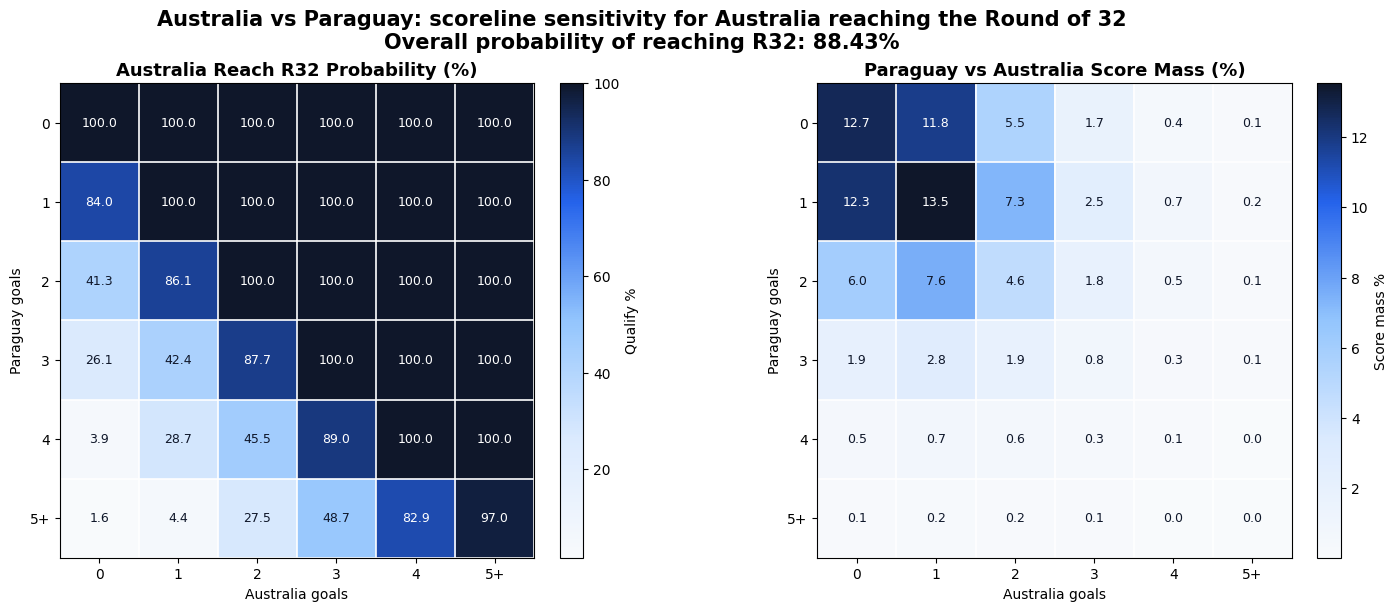

In [108]:
# AUS-PAR R32 MATRIX VISUALISATION
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

heatmap_cmap = LinearSegmentedColormap.from_list(
    "aus_par_heat",
    ["#f8fafc", "#dbeafe", "#93c5fd", "#2563eb", "#0f172a"],
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

plots = [
    (axes[0], qual_pct_df, "Australia Reach R32 Probability (%)", "Qualify %"),
    (axes[1], score_mass_pct_df, "Paraguay vs Australia Score Mass (%)", "Score mass %"),
]

for ax, df, title, cbar_label in plots:
    image = ax.imshow(df.values, cmap=heatmap_cmap, aspect="equal")
    ax.set_title(title, fontsize=13, weight="semibold")
    ax.set_xlabel("Australia goals")
    ax.set_ylabel("Paraguay goals")
    ax.set_xticks(range(len(df.columns)), df.columns)
    ax.set_yticks(range(len(df.index)), df.index)
    ax.set_xticks(np.arange(-0.5, len(df.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(df.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    max_value = float(np.nanmax(df.values))
    for row_index in range(df.shape[0]):
        for col_index in range(df.shape[1]):
            value = float(df.iat[row_index, col_index])
            text_color = "white" if value > 0.6 * max_value else "#0f172a"
            ax.text(col_index, row_index, f"{value:.1f}", ha="center", va="center", fontsize=9, color=text_color)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(cbar_label)

fig.suptitle(
    f"Australia vs Paraguay: scoreline sensitivity for Australia reaching the Round of 32\nOverall probability of reaching R32: {overall_aus_r32_probability:.2%}",
    fontsize=15,
    weight="bold",
)
plt.show()


In [116]:
# AUS-R32 BY REMAINING GROUP MATCH OUTCOME
# For every remaining group-stage match, compute Australia's Round of 32 probability
# conditional on the outright result only: home win / draw / away win.
#
# Main 'matters' metric:
#   pivotal_probability = probability that, holding every other simulated match fixed,
#   at least one pair among {home win, draw, away win} flips Australia between making
#   and missing the Round of 32.
#
# This is a true probability that the game matters for Australia.

import csv

with open("web/public/model_output/results_wc2026.csv", "r") as f:
    results_rows = list(csv.DictReader(f))
completed_group_match_ids = {
    int(row["match_id"])
    for row in results_rows
    if row.get("stage") == "Group"
    and str(row.get("home_score", "")).strip() not in {"", "NA", "nan"}
    and str(row.get("away_score", "")).strip() not in {"", "NA", "nan"}
}

with open("reference_data/world_cup_2026_group_matches.csv", "r") as f:
    all_group_match_rows = list(csv.DictReader(f))

remaining_group_matches = [
    row for row in all_group_match_rows if int(row["match_id"]) not in completed_group_match_ids
]
match_meta_by_id = {int(row["match_id"]): row for row in remaining_group_matches}
ref_match_by_id = {int(row["match_id"]): row for row in all_group_match_rows}
GROUP_TO_TEAMS = {group: [] for group in GROUPS}
for row in all_group_match_rows:
    GROUP_TO_TEAMS[row["group"]].append(row["home_team"])
    GROUP_TO_TEAMS[row["group"]].append(row["away_team"])
GROUP_TO_TEAMS = {group: sorted(set(teams)) for group, teams in GROUP_TO_TEAMS.items()}

AUS_R32_STAGE_ID = 1
OUTCOME_SCORELINES = {
    "home_win": (1, 0),
    "draw": (0, 0),
    "away_win": (0, 1),
}


def australia_reaches_r32_in_run(run):
    return any(
        match[0] == AUS_R32_STAGE_ID and (match[2] == AUS_ID or match[3] == AUS_ID)
        for match in run["m"]
    )


def orient_score_for_reference(match, ref_home_id, ref_away_id):
    if (match[2], match[3]) == (ref_home_id, ref_away_id):
        return int(match[4]), int(match[5])
    if (match[2], match[3]) == (ref_away_id, ref_home_id):
        return int(match[5]), int(match[4])
    raise ValueError("Match orientation mismatch")


def build_group_table_for_run(run, group_name, override_match_id=None, override_score=None):
    table = {team: blank_stats() for team in GROUP_TO_TEAMS[group_name]}
    matches = []
    group_index = GROUPS.index(group_name)
    group_match_rows = [row for row in all_group_match_rows if row["group"] == group_name]
    for row in group_match_rows:
        match_id = int(row["match_id"])
        home_team = row["home_team"]
        away_team = row["away_team"]
        if match_id == override_match_id and override_score is not None:
            home_score, away_score = override_score
        else:
            home_id = team_to_id[home_team]
            away_id = team_to_id[away_team]
            sim_match = next(
                match
                for match in run["m"]
                if match[0] == 0 and match[1] == group_index
                and ((match[2], match[3]) == (home_id, away_id) or (match[2], match[3]) == (away_id, home_id))
            )
            home_score, away_score = orient_score_for_reference(sim_match, home_id, away_id)
        apply_match(table, home_team, away_team, home_score, away_score)
        matches.append((home_team, away_team, home_score, away_score))
    ranking = rank_group(table, matches)
    return table, ranking


# Precompute the baseline facts we need from each run.
run_aus_r32 = []
run_aus_rank = []
run_aus_row = []
run_other_group_third_rows = []
run_outrank_flags = []
for run in simulation_runs:
    run_aus_r32.append(australia_reaches_r32_in_run(run))

    d_table, d_ranking = build_group_table_for_run(run, "D")
    aus_rank = d_ranking.index("Australia") + 1
    run_aus_rank.append(aus_rank)
    aus_stats = d_table["Australia"]
    aus_row = (aus_stats["pts"], aus_stats["gd"], aus_stats["gf"])
    run_aus_row.append(aus_row)

    third_rows = {}
    outrank_flags = {}
    for group_name in GROUPS:
        if group_name == "D":
            continue
        third_row = run["gt"][GROUPS.index(group_name)][2]
        row_tuple = (int(third_row[1]), int(third_row[2]), int(third_row[3]))
        third_rows[group_name] = row_tuple
        outrank_flags[group_name] = row_tuple > aus_row
    run_other_group_third_rows.append(third_rows)
    run_outrank_flags.append(outrank_flags)

overall_aus_r32_prob = float(np.mean(run_aus_r32))

rows = []
for match_id, meta_row in match_meta_by_id.items():
    home_team = meta_row["home_team"]
    away_team = meta_row["away_team"]
    home_id = team_to_id[home_team]
    away_id = team_to_id[away_team]
    group_name = meta_row["group"]

    outcome_buckets = {
        "home_win": {"count": 0, "aus_yes": 0},
        "draw": {"count": 0, "aus_yes": 0},
        "away_win": {"count": 0, "aus_yes": 0},
    }
    pivotal_count = 0

    for run_index, run in enumerate(simulation_runs):
        sim_match = next(
            match
            for match in run["m"]
            if match[0] == 0
            and ((match[2], match[3]) == (home_id, away_id) or (match[2], match[3]) == (away_id, home_id))
        )
        actual_home_score, actual_away_score = orient_score_for_reference(sim_match, home_id, away_id)
        if actual_home_score > actual_away_score:
            realized_outcome = "home_win"
        elif actual_away_score > actual_home_score:
            realized_outcome = "away_win"
        else:
            realized_outcome = "draw"
        outcome_buckets[realized_outcome]["count"] += 1
        outcome_buckets[realized_outcome]["aus_yes"] += int(run_aus_r32[run_index])

        alt_statuses = {}
        for outcome_key, scoreline in OUTCOME_SCORELINES.items():
            if group_name != "D":
                aus_rank = run_aus_rank[run_index]
                if aus_rank <= 2:
                    alt_statuses[outcome_key] = True
                    continue
                if aus_rank == 4:
                    alt_statuses[outcome_key] = False
                    continue

                third_table, third_ranking = build_group_table_for_run(
                    run,
                    group_name,
                    override_match_id=match_id,
                    override_score=scoreline,
                )
                third_team = third_ranking[2]
                third_stats = third_table[third_team]
                third_row = (third_stats["pts"], third_stats["gd"], third_stats["gf"])
                baseline_outrank_count = sum(run_outrank_flags[run_index].values())
                adjusted_outrank_count = baseline_outrank_count - int(run_outrank_flags[run_index][group_name]) + int(third_row > run_aus_row[run_index])
                alt_statuses[outcome_key] = adjusted_outrank_count <= 7
            else:
                d_table, d_ranking = build_group_table_for_run(
                    run,
                    "D",
                    override_match_id=match_id,
                    override_score=scoreline,
                )
                aus_rank = d_ranking.index("Australia") + 1
                if aus_rank <= 2:
                    alt_statuses[outcome_key] = True
                    continue
                if aus_rank == 4:
                    alt_statuses[outcome_key] = False
                    continue

                aus_stats = d_table["Australia"]
                aus_row = (aus_stats["pts"], aus_stats["gd"], aus_stats["gf"])
                outrank_count = sum(row > aus_row for row in run_other_group_third_rows[run_index].values())
                alt_statuses[outcome_key] = outrank_count <= 7

        if len(set(alt_statuses.values())) > 1:
            pivotal_count += 1

    outcome_probs = {}
    cond_probs = {}
    for outcome_key, bucket in outcome_buckets.items():
        outcome_prob = bucket["count"] / len(simulation_runs)
        cond_prob = bucket["aus_yes"] / bucket["count"] if bucket["count"] else np.nan
        outcome_probs[outcome_key] = outcome_prob
        cond_probs[outcome_key] = cond_prob

    importance = sum(
        outcome_probs[key] * abs(cond_probs[key] - overall_aus_r32_prob)
        for key in outcome_buckets
        if np.isfinite(cond_probs[key])
    )
    range_pp = 100 * (
        max(v for v in cond_probs.values() if np.isfinite(v))
        - min(v for v in cond_probs.values() if np.isfinite(v))
    )

    rows.append({
        "match_id": match_id,
        "group": group_name,
        "match": f"{home_team} vs {away_team}",
        "p_home_win": outcome_probs["home_win"],
        "p_draw": outcome_probs["draw"],
        "p_away_win": outcome_probs["away_win"],
        "aus_r32_if_home_win": cond_probs["home_win"],
        "aus_r32_if_draw": cond_probs["draw"],
        "aus_r32_if_away_win": cond_probs["away_win"],
        "aus_miss_if_home_win": 1 - cond_probs["home_win"] if np.isfinite(cond_probs["home_win"]) else np.nan,
        "aus_miss_if_draw": 1 - cond_probs["draw"] if np.isfinite(cond_probs["draw"]) else np.nan,
        "aus_miss_if_away_win": 1 - cond_probs["away_win"] if np.isfinite(cond_probs["away_win"]) else np.nan,
        "pivotal_probability": pivotal_count / len(simulation_runs),
        "outcome_importance": importance,
        "range_pp": range_pp,
    })

outcome_importance_df = pd.DataFrame(rows).sort_values(
    ["pivotal_probability", "outcome_importance"],
    ascending=[False, False],
).reset_index(drop=True)

display_df = outcome_importance_df.assign(
    p_home_win_pct=lambda df: df["p_home_win"] * 100,
    p_draw_pct=lambda df: df["p_draw"] * 100,
    p_away_win_pct=lambda df: df["p_away_win"] * 100,
    aus_r32_if_home_win_pct=lambda df: df["aus_r32_if_home_win"] * 100,
    aus_r32_if_draw_pct=lambda df: df["aus_r32_if_draw"] * 100,
    aus_r32_if_away_win_pct=lambda df: df["aus_r32_if_away_win"] * 100,
    aus_miss_if_home_win_pct=lambda df: df["aus_miss_if_home_win"] * 100,
    aus_miss_if_draw_pct=lambda df: df["aus_miss_if_draw"] * 100,
    aus_miss_if_away_win_pct=lambda df: df["aus_miss_if_away_win"] * 100,
    pivotal_probability_pct=lambda df: df["pivotal_probability"] * 100,
    outcome_importance_pp=lambda df: df["outcome_importance"] * 100,
)[[
    "group",
    "match",
    "p_home_win_pct",
    "p_draw_pct",
    "p_away_win_pct",
    "aus_r32_if_home_win_pct",
    "aus_r32_if_draw_pct",
    "aus_r32_if_away_win_pct",
    "aus_miss_if_home_win_pct",
    "aus_miss_if_draw_pct",
    "aus_miss_if_away_win_pct",
    "pivotal_probability_pct",
    "outcome_importance_pp",
    "range_pp",
]].rename(columns={
    "group": "Group",
    "match": "Match",
    "p_home_win_pct": "P(H) %",
    "p_draw_pct": "P(D) %",
    "p_away_win_pct": "P(A) %",
    "aus_r32_if_home_win_pct": "Aus R32 if H %",
    "aus_r32_if_draw_pct": "Aus R32 if D %",
    "aus_r32_if_away_win_pct": "Aus R32 if A %",
    "aus_miss_if_home_win_pct": "Aus miss if H %",
    "aus_miss_if_draw_pct": "Aus miss if D %",
    "aus_miss_if_away_win_pct": "Aus miss if A %",
    "pivotal_probability_pct": "P(game matters) %",
    "outcome_importance_pp": "Importance (pp)",
    "range_pp": "Range (pp)",
}).round(2)

print(f"Australia unconditional Reach R32 probability across simulations: {overall_aus_r32_prob:.2%}")
display(display_df)


Australia unconditional Reach R32 probability across simulations: 88.02%


,Group,Match,P(H) %,P(D) %,P(A) %,Aus R32 if H %,Aus R32 if D %,Aus R32 if A %,Aus miss if H %,Aus miss if D %,Aus miss if A %,P(game matters) %,Importance (pp),Range (pp)
0,D,Paraguay vs Australia,36.50,30.00,33.50,67.18,100.00,100.00,32.82,0.00,0.00,15.95,15.21,32.82
1,H,Uruguay vs Spain,17.52,22.37,60.11,80.94,83.24,91.86,19.06,16.76,8.14,8.38,4.62,10.93
2,J,Algeria vs Austria,29.46,24.19,46.35,84.56,84.33,92.15,15.44,15.67,7.85,7.99,3.83,7.81
3,K,DR Congo vs Uzbekistan,38.93,29.69,31.38,81.86,91.95,91.94,18.14,8.05,8.06,7.89,4.79,10.09
4,G,Egypt vs Iran,28.85,31.59,39.56,94.21,85.31,85.67,5.79,14.69,14.33,6.57,3.57,8.90
5,I,Senegal vs Iraq,61.77,24.57,13.66,85.06,92.10,94.07,14.94,7.90,5.93,4.21,3.66,9.01
6,L,Croatia vs Ghana,63.31,22.23,14.46,87.58,87.13,91.29,12.42,12.87,8.71,3.02,0.94,4.15
7,J,Jordan vs Argentina,3.73,10.46,85.81,90.08,87.86,87.95,9.92,12.14,12.05,1.55,0.15,2.22
8,D,Turkey vs USA,25.83,25.49,48.68,87.26,88.74,88.04,12.74,11.26,11.96,1.43,0.39,1.48
9,L,Panama vs England,5.96,13.89,80.15,87.42,87.19,88.21,12.58,12.81,11.79,0.19,0.30,1.02


In [117]:
# AUS-R32 BY REMAINING GROUP MATCH OUTCOME | CONDITIONAL ON PARAGUAY BEATING AUSTRALIA
# Reuses the setup from the previous cell, but conditions on worlds where Paraguay beat Australia.
# No resimulation: this is just a filtered view of the same simulation ensemble.

from pathlib import Path

with open("reference_data/fifa_country_codes.csv", "r") as f:
    FIFA_CODE_MAP = {row["team"]: row["fifa_code"] for row in csv.DictReader(f)}

def team_code(team):
    return FIFA_CODE_MAP.get(team, team[:3].upper())

def flag_path(team):
    return Path("web/public/flags") / f"{team.replace(' ', '_')}.png"

def team_label_html(team):
    code = team_code(team)
    src = flag_path(team).as_posix()
    return (
        f'<span style="white-space:nowrap;">'
        f'<img src="{src}" style="width:18px;height:12px;object-fit:cover;border-radius:1px;'
        f'border:1px solid rgba(0,0,0,0.12);vertical-align:middle;margin-right:6px;display:inline-block;" />'
        f'<span style="vertical-align:middle;display:inline;">{code}</span></span>'
    )

par_aus_match_id = next(
    match_id
    for match_id, row in match_meta_by_id.items()
    if row["home_team"] == "Paraguay" and row["away_team"] == "Australia"
)
par_aus_home_id = team_to_id["Paraguay"]
par_aus_away_id = team_to_id["Australia"]

par_aus_home_win_run_indices = []
for run_index, run in enumerate(simulation_runs):
    sim_match = next(
        match
        for match in run["m"]
        if match[0] == 0
        and ((match[2], match[3]) == (par_aus_home_id, par_aus_away_id) or (match[2], match[3]) == (par_aus_away_id, par_aus_home_id))
    )
    home_score, away_score = orient_score_for_reference(sim_match, par_aus_home_id, par_aus_away_id)
    if home_score > away_score:
        par_aus_home_win_run_indices.append(run_index)

conditional_run_count = len(par_aus_home_win_run_indices)
conditional_overall_aus_r32_prob = float(np.mean([run_aus_r32[i] for i in par_aus_home_win_run_indices]))

conditional_rows = []
for match_id, meta_row in match_meta_by_id.items():
    if match_id == par_aus_match_id:
        continue

    home_team = meta_row["home_team"]
    away_team = meta_row["away_team"]
    home_id = team_to_id[home_team]
    away_id = team_to_id[away_team]
    group_name = meta_row["group"]

    outcome_buckets = {
        "home_win": {"count": 0, "aus_yes": 0},
        "draw": {"count": 0, "aus_yes": 0},
        "away_win": {"count": 0, "aus_yes": 0},
    }
    pivotal_count = 0

    for run_index in par_aus_home_win_run_indices:
        run = simulation_runs[run_index]
        sim_match = next(
            match
            for match in run["m"]
            if match[0] == 0
            and ((match[2], match[3]) == (home_id, away_id) or (match[2], match[3]) == (away_id, home_id))
        )
        actual_home_score, actual_away_score = orient_score_for_reference(sim_match, home_id, away_id)
        if actual_home_score > actual_away_score:
            realized_outcome = "home_win"
        elif actual_away_score > actual_home_score:
            realized_outcome = "away_win"
        else:
            realized_outcome = "draw"
        outcome_buckets[realized_outcome]["count"] += 1
        outcome_buckets[realized_outcome]["aus_yes"] += int(run_aus_r32[run_index])

        alt_statuses = {}
        for outcome_key, scoreline in OUTCOME_SCORELINES.items():
            if group_name != "D":
                aus_rank = run_aus_rank[run_index]
                if aus_rank <= 2:
                    alt_statuses[outcome_key] = True
                    continue
                if aus_rank == 4:
                    alt_statuses[outcome_key] = False
                    continue

                third_table, third_ranking = build_group_table_for_run(
                    run,
                    group_name,
                    override_match_id=match_id,
                    override_score=scoreline,
                )
                third_team = third_ranking[2]
                third_stats = third_table[third_team]
                third_row = (third_stats["pts"], third_stats["gd"], third_stats["gf"])
                baseline_outrank_count = sum(run_outrank_flags[run_index].values())
                adjusted_outrank_count = baseline_outrank_count - int(run_outrank_flags[run_index][group_name]) + int(third_row > run_aus_row[run_index])
                alt_statuses[outcome_key] = adjusted_outrank_count <= 7
            else:
                d_table, d_ranking = build_group_table_for_run(
                    run,
                    "D",
                    override_match_id=match_id,
                    override_score=scoreline,
                )
                aus_rank = d_ranking.index("Australia") + 1
                if aus_rank <= 2:
                    alt_statuses[outcome_key] = True
                    continue
                if aus_rank == 4:
                    alt_statuses[outcome_key] = False
                    continue

                aus_stats = d_table["Australia"]
                aus_row = (aus_stats["pts"], aus_stats["gd"], aus_stats["gf"])
                outrank_count = sum(row > aus_row for row in run_other_group_third_rows[run_index].values())
                alt_statuses[outcome_key] = outrank_count <= 7

        if len(set(alt_statuses.values())) > 1:
            pivotal_count += 1

    outcome_probs = {}
    cond_probs = {}
    for outcome_key, bucket in outcome_buckets.items():
        outcome_prob = bucket["count"] / conditional_run_count if conditional_run_count else np.nan
        cond_prob = bucket["aus_yes"] / bucket["count"] if bucket["count"] else np.nan
        outcome_probs[outcome_key] = outcome_prob
        cond_probs[outcome_key] = cond_prob

    importance = sum(
        outcome_probs[key] * abs(cond_probs[key] - conditional_overall_aus_r32_prob)
        for key in outcome_buckets
        if np.isfinite(cond_probs[key]) and np.isfinite(outcome_probs[key])
    )
    range_pp = 100 * (
        max(v for v in cond_probs.values() if np.isfinite(v))
        - min(v for v in cond_probs.values() if np.isfinite(v))
    )

    timing_bucket = "Before" if meta_row["date"] < ref_match_by_id[par_aus_match_id]["date"] else "After"

    conditional_rows.append({
        "match_id": match_id,
        "date": meta_row["date"],
        "timing": timing_bucket,
        "group": group_name,
        "home_team": home_team,
        "away_team": away_team,
        "p_home_win": outcome_probs["home_win"],
        "p_draw": outcome_probs["draw"],
        "p_away_win": outcome_probs["away_win"],
        "aus_r32_if_home_win": cond_probs["home_win"],
        "aus_r32_if_draw": cond_probs["draw"],
        "aus_r32_if_away_win": cond_probs["away_win"],
        "pivotal_probability": pivotal_count / conditional_run_count if conditional_run_count else np.nan,
        "outcome_importance": importance,
        "range_pp": range_pp,
    })

conditional_outcome_importance_df = pd.DataFrame(conditional_rows)
conditional_outcome_importance_df["timing_sort"] = conditional_outcome_importance_df["timing"].map({"Before": 0, "After": 1})
conditional_outcome_importance_df["best_outcome"] = conditional_outcome_importance_df[[
    "aus_r32_if_home_win",
    "aus_r32_if_draw",
    "aus_r32_if_away_win",
]].idxmax(axis=1)
conditional_outcome_importance_df = conditional_outcome_importance_df.sort_values(
    ["timing_sort", "date", "match_id"],
    ascending=[True, True, True],
).reset_index(drop=True)

conditional_display_df = conditional_outcome_importance_df[[
    "date",
    "timing",
    "group",
    "home_team",
    "away_team",
    "p_home_win",
    "p_draw",
    "p_away_win",
    "aus_r32_if_home_win",
    "aus_r32_if_draw",
    "aus_r32_if_away_win",
    "pivotal_probability",
    "outcome_importance",
    "range_pp",
]].rename(columns={
    "date": "Date",
    "timing": "When",
    "group": "Group",
    "home_team": "Home",
    "away_team": "Away",
})

conditional_display_df["Matters"] = (conditional_display_df["pivotal_probability"] * 100).round(1)
conditional_display_df["Importance"] = (conditional_display_df["outcome_importance"] * 100).round(1)
conditional_display_df["Range"] = conditional_display_df["range_pp"].round(1)

from IPython.display import HTML

def color_for_aus_prob(aus_prob_pct_exact):
    delta = float(aus_prob_pct_exact - conditional_overall_aus_r32_prob * 100)
    strength = min(abs(delta) / 20.0, 1.0)
    alpha = 0.10 + 0.30 * strength
    if delta >= 0:
        return f"rgba(22, 163, 74, {alpha:.3f})"
    return f"rgba(220, 38, 38, {alpha:.3f})"


def scalar_background(value, max_value, rgb):
    strength = min(max(float(value), 0.0) / max_value, 1.0)
    alpha = 0.06 + 0.28 * strength
    return f"rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, {alpha:.3f})"

def importance_background(importance_pp):
    return scalar_background(importance_pp, 5.0, (147, 51, 234))

def matters_background(matters_pct):
    return scalar_background(matters_pct, 15.0, (202, 138, 4))

def range_background(range_pp):
    return scalar_background(range_pp, 20.0, (37, 99, 235))

def format_prob_cell(result_prob, aus_prob):
    result_pct = int(round(result_prob * 100))
    aus_pct = int(round(aus_prob * 100))
    background = color_for_aus_prob(aus_pct)
    return (
        f'<span style="display:inline-block; min-width:72px; padding:2px 6px; '
        f'border-radius:6px; background:{background}; text-align:center;">'
        f'{aus_pct} ({result_pct})</span>'
    )

conditional_display_html_df = pd.DataFrame({
    "Date": conditional_display_df["Date"],
    "When": conditional_display_df["When"],
    "Group": conditional_display_df["Group"],
    "Home": [team_label_html(team) for team in conditional_display_df["Home"]],
    "PR(H)": [
        format_prob_cell(r, a)
        for r, a in zip(
            conditional_display_df["p_home_win"],
            conditional_display_df["aus_r32_if_home_win"],
        )
    ],
    "PR(D)": [
        format_prob_cell(r, a)
        for r, a in zip(
            conditional_display_df["p_draw"],
            conditional_display_df["aus_r32_if_draw"],
        )
    ],
    "PR(A)": [
        format_prob_cell(r, a)
        for r, a in zip(
            conditional_display_df["p_away_win"],
            conditional_display_df["aus_r32_if_away_win"],
        )
    ],
    "Away": [team_label_html(team) for team in conditional_display_df["Away"]],
    "Matters": [
        f'<span style="display:inline-block; min-width:52px; padding:2px 6px; border-radius:6px; background:{matters_background(v)}; text-align:center;">{v:.1f}</span>'
        for v in conditional_display_df["Matters"]
    ],
    "Importance": [
        f'<span style="display:inline-block; min-width:52px; padding:2px 6px; border-radius:6px; background:{importance_background(v)}; text-align:center;">{v:.1f}</span>'
        for v in conditional_display_df["Importance"]
    ],
    "Range": [
        f'<span style="display:inline-block; min-width:52px; padding:2px 6px; border-radius:6px; background:{range_background(v)}; text-align:center;">{v:.1f}</span>'
        for v in conditional_display_df["Range"]
    ],
})

print(f"Conditional run count with Paraguay beating Australia: {conditional_run_count}")
print(f"Australia Reach R32 probability conditional on Paraguay beating Australia: {conditional_overall_aus_r32_prob:.2%}")
print("Importance (pp): expected absolute shift in Australia make probability once you learn H/D/A.")
print("Range (pp): max minus min across Pr(Aus make | H), Pr(Aus make | D), Pr(Aus make | A).")
display(HTML(conditional_display_html_df.to_html(index=False, escape=False)))


Conditional run count with Paraguay beating Australia: 3650
Australia Reach R32 probability conditional on Paraguay beating Australia: 67.18%
Importance (pp): expected absolute shift in Australia make probability once you learn H/D/A.
Range (pp): max minus min across Pr(Aus make | H), Pr(Aus make | D), Pr(Aus make | A).


Date,When,Group,Home,PR(H),PR(D),PR(A),Away,Matters,Importance,Range
2026-06-25,After,D,TUR,65 (26),69 (26),67 (48),USA,3.9,1.0,3.8
2026-06-26,After,I,NOR,69 (24),70 (24),65 (51),FRA,0.0,2.3,5.4
2026-06-26,After,I,SEN,59 (62),79 (25),83 (13),IRQ,11.5,9.9,24.2
2026-06-26,After,G,EGY,84 (29),60 (32),60 (39),IRN,18.0,9.6,23.5
2026-06-26,After,G,NZL,67 (7),69 (15),67 (77),BEL,0.0,0.5,2.2
2026-06-26,After,H,CPV,68 (35),66 (31),68 (34),KSA,0.0,0.6,1.5
2026-06-26,After,H,URU,49 (18),52 (21),78 (61),ESP,23.0,13.1,29.2
2026-06-27,After,L,PAN,67 (6),65 (14),68 (80),ENG,0.5,0.7,3.1
2026-06-27,After,L,CRO,66 (63),65 (23),76 (14),GHA,8.3,2.5,10.6
2026-06-27,After,J,ALG,58 (29),56 (23),79 (47),AUT,21.9,11.1,23.4


In [113]:
# EXPORT CONDITIONAL TABLE PNG
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_export_columns = ["Date", "Group", "Home", "HomeCode", "PR(H)", "PR(D)", "PR(A)", "Away", "AwayCode", "Matters", "Importance", "Range"]
export_df = conditional_display_df.copy()
export_df["HomeCode"] = export_df["Home"].map(team_code)
export_df["AwayCode"] = export_df["Away"].map(team_code)
export_df["PR(H)"] = [
    f"{int(round(a * 100))} ({int(round(r * 100))})"
    for r, a in zip(export_df["p_home_win"], export_df["aus_r32_if_home_win"])
]
export_df["PR(D)"] = [
    f"{int(round(a * 100))} ({int(round(r * 100))})"
    for r, a in zip(export_df["p_draw"], export_df["aus_r32_if_draw"])
]
export_df["PR(A)"] = [
    f"{int(round(a * 100))} ({int(round(r * 100))})"
    for r, a in zip(export_df["p_away_win"], export_df["aus_r32_if_away_win"])
]
export_df["Matters"] = [f"{v:.1f}" for v in export_df["Matters"]]
export_df["Importance"] = [f"{v:.1f}" for v in export_df["Importance"]]
export_df["Range"] = [f"{v:.1f}" for v in export_df["Range"]]

before_df = export_df[export_df["When"] == "Before"][base_export_columns].copy()
after_df = export_df[export_df["When"] == "After"][base_export_columns].copy()
separator_row = {
    "Date": ref_match_by_id[par_aus_match_id]["date"],
    "Group": "D",
    "Home": "",
    "HomeCode": "",
    "PR(H)": "Australia vs Paraguay",
    "PR(D)": "",
    "PR(A)": "",
    "Away": "",
    "AwayCode": "",
    "Matters": "",
    "Importance": "",
    "Range": "",
}
render_df = pd.concat([before_df, pd.DataFrame([separator_row]), after_df], ignore_index=True)
separator_index = len(before_df)
visible_columns = ["Date", "Group", "HomeCode", "PR(H)", "PR(D)", "PR(A)", "AwayCode", "Matters", "Importance", "Range"]


def css_rgba_to_mpl_tuple(css_rgba):
    parts = css_rgba.removeprefix("rgba(").removesuffix(")").split(",")
    r, g, b = [int(part.strip()) / 255 for part in parts[:3]]
    a = float(parts[3].strip())
    return (r, g, b, a)

n_rows = len(render_df)
fig_height = max(6, 0.34 * (n_rows + 1))
fig, ax = plt.subplots(figsize=(14.4, fig_height))
ax.axis("off")
col_widths = [0.09, 0.03, 0.12, 0.105, 0.105, 0.105, 0.12, 0.05, 0.05, 0.05]

table = ax.table(
    cellText=render_df[visible_columns].values,
    colLabels=["Date", "G", "Home", "PR(H)", "PR(D)", "PR(A)", "Away", "Matters", "Importance", "Range"],
    cellLoc="center",
    colLoc="center",
    colWidths=col_widths,
    loc="upper left",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.45)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

flag_cache = {}
def get_flag(team):
    if team not in flag_cache:
        flag_cache[team] = mpimg.imread(flag_path(team))
    return flag_cache[team]

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#e5e7eb")
        cell.set_text_props(weight="bold", color="#111827")
        cell.set_edgecolor("#d1d5db")
        continue

    data_idx = row - 1
    cell.set_edgecolor("#e5e7eb")
    cell.set_facecolor("white")

    if data_idx == separator_index:
        cell.set_facecolor("#111827")
        cell.set_edgecolor("#0f172a")
        cell.get_text().set_color("white")
        cell.get_text().set_weight("bold")
        if col not in [0, 1, 3]:
            cell.get_text().set_text("")
        if col == 3:
            cell.get_text().set_text("Australia vs Paraguay")
        continue

    source_idx = data_idx if data_idx < separator_index else data_idx - 1
    source_row = conditional_display_df.iloc[source_idx]

    if col == 3:
        cell.set_facecolor(css_rgba_to_mpl_tuple(color_for_aus_prob(source_row["aus_r32_if_home_win"] * 100)))
    elif col == 4:
        cell.set_facecolor(css_rgba_to_mpl_tuple(color_for_aus_prob(source_row["aus_r32_if_draw"] * 100)))
    elif col == 5:
        cell.set_facecolor(css_rgba_to_mpl_tuple(color_for_aus_prob(source_row["aus_r32_if_away_win"] * 100)))
    elif col == 7:
        cell.set_facecolor(css_rgba_to_mpl_tuple(matters_background(source_row["Matters"])))
    elif col == 8:
        cell.set_facecolor(css_rgba_to_mpl_tuple(importance_background(source_row["Importance"])))
    elif col == 9:
        cell.set_facecolor(css_rgba_to_mpl_tuple(range_background(source_row["Range"])))

for col, team_field, code_field in [(2, "Home", "HomeCode"), (6, "Away", "AwayCode")]:
    for row_idx in range(1, len(render_df) + 1):
        data_idx = row_idx - 1
        if data_idx == separator_index:
            continue
        team = render_df.iloc[data_idx][team_field]
        code = render_df.iloc[data_idx][code_field]
        cell = table[(row_idx, col)]
        cell.get_text().set_text("")
        bbox = cell.get_window_extent(renderer).transformed(fig.transFigure.inverted())
        x0, y0, w, h = bbox.x0, bbox.y0, bbox.width, bbox.height
        img_w = h * 1.10
        img_h = h * 0.56
        img_ax = fig.add_axes([x0 + 0.004, y0 + (h - img_h) / 2, img_w, img_h])
        img_ax.imshow(get_flag(team))
        img_ax.axis('off')
        fig.text(
            x0 + img_w + 0.008,
            y0 + h / 2,
            code,
            ha='left',
            va='center',
            fontsize=8,
            fontweight='semibold',
            color='#111827',
        )

output_path = Path("tmp/aus_paraguay_conditional_table.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.close(fig)
print(f"Saved PNG to {output_path}")


Saved PNG to tmp/aus_paraguay_conditional_table.png


In [118]:
# AUS VS EACH GROUP'S THIRD-PLACE TEAM | CONDITIONAL ON PARAGUAY BEATING AUSTRALIA
# No resimulation: reuses the filtered world set from the previous cells.

from collections import Counter

group_names = list(GROUPS)

group_rows = []
for group_name in group_names:
    outrank_count = 0
    third_place_counts = Counter()

    for run_index in par_aus_home_win_run_indices:
        run = simulation_runs[run_index]

        if group_name == "D":
            # Conditional on Paraguay beating Australia, Australia are always the
            # third-placed team in Group D. Turkey can at best tie on points, but
            # Australia beat Turkey head-to-head.
            third_team = "Australia"
            third_row = run_aus_row[run_index]
        else:
            group_index = GROUPS.index(group_name)
            third_team = teams[run["gr"][group_index][2]]
            third_row = run_other_group_third_rows[run_index][group_name]

        third_place_counts[third_team] += 1
        outrank_count += int(run_aus_row[run_index] > third_row)

    likeliest_third_team, likeliest_third_count = third_place_counts.most_common(1)[0]
    group_rows.append({
        "Group": group_name,
        "Likeliest 3rd": likeliest_third_team,
        "Pr(3rd = Likeliest)": likeliest_third_count / conditional_run_count,
        "Pr(Aus > 3rd | Par > Aus)": outrank_count / conditional_run_count,
    })

aus_vs_group_third_df = pd.DataFrame(group_rows)
aus_vs_group_third_df["Pr(3rd = Likeliest)"] = (100 * aus_vs_group_third_df["Pr(3rd = Likeliest)"]).round(1)
aus_vs_group_third_df["Pr(Aus > 3rd | Par > Aus)"] = (100 * aus_vs_group_third_df["Pr(Aus > 3rd | Par > Aus)"]).round(1)
aus_vs_group_third_df.sort_values("Pr(Aus > 3rd | Par > Aus)", ascending=False, inplace=True)
aus_vs_group_third_df.sort_values("Group")

,Group,Likeliest 3rd,Pr(3rd = Likeliest),Pr(Aus > 3rd | Par > Aus)
0,A,South Korea,100.0,27.2
1,B,Bosnia and Herzegovina,100.0,0.0
2,C,Scotland,100.0,96.5
3,D,Australia,100.0,0.0
4,E,Ecuador,100.0,0.0
5,F,Sweden,100.0,0.0
6,G,Iran,54.5,28.5
7,H,Uruguay,65.1,60.7
8,I,Senegal,86.7,54.2
9,J,Algeria,70.6,53.1


In [119]:
aus_vs_group_third_df.iloc[:,-1].sum()

np.float64(390.6)